# 0. Assess the quality of the cells and gene features

## Imports

In [2]:
import scanpy as sc
import numpy as np
import scipy as sp
import os, sys

#### Load data

In [3]:
os.chdir('../../data')

In [4]:
d2_dz = sc.read_h5ad('egfDuod_D2_DZ.h5ad')

In [5]:
d2_dz

AnnData object with n_obs × n_vars = 46210 × 27844
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident'
    uns: 'X_name'
    layers: 'counts'

#### Assign var df columns corresponding to quality features of the genes; are they mitochondrial or ribosomal

In [6]:
d2_dz.var["mt"] = d2_dz.var_names.str.startswith("MT-")

In [7]:
d2_dz

AnnData object with n_obs × n_vars = 46210 × 27844
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident'
    var: 'mt'
    uns: 'X_name'
    layers: 'counts'

In [8]:
d2_dz.var["ribo"] = d2_dz.var_names.str.startswith(("RPS", "RPL"))


#### Calculate and plot the built in scanpy qc

In [9]:
sc.pp.calculate_qc_metrics(d2_dz, qc_vars=["mt", "ribo"], inplace=True, log1p=True)

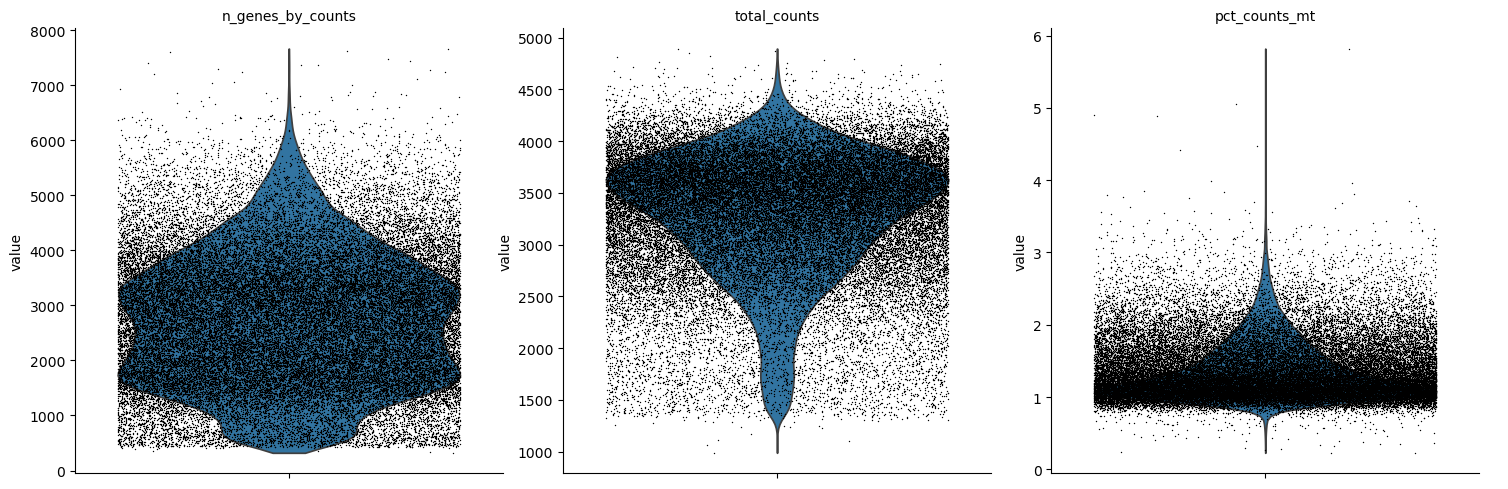

In [10]:
sc.pl.violin(
    d2_dz,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

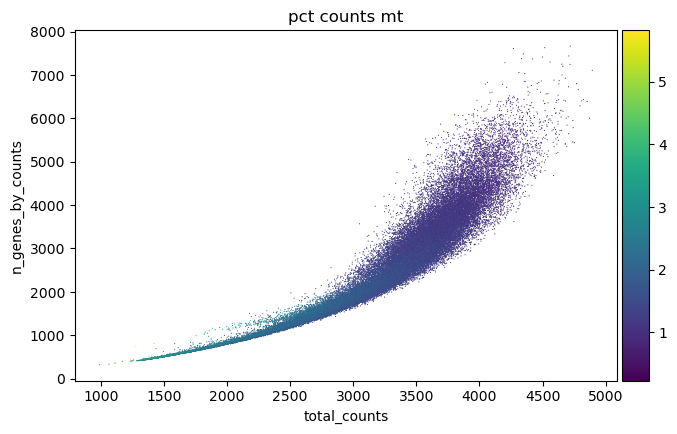

In [11]:
sc.pl.scatter(d2_dz, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [12]:
d2_dz.obs[['n_genes_by_counts','total_counts','pct_counts_mt']].describe()


,n_genes_by_counts,total_counts,pct_counts_mt
count,46210.000000,46210.000000,46210.000000
mean,2729.766782,3276.763002,1.368183
std,1201.740793,612.680134,0.418661
min,322.000000,990.418266,0.229953
25%,1783.000000,2930.509254,1.066708
50%,2693.000000,3400.411869,1.241437
75%,3567.000000,3717.542036,1.576117
max,7666.000000,4893.684014,5.819432


#### Run scrublet for droplet quality control

In [13]:
sc.pp.scrublet(d2_dz)

In [14]:
d2_dz

AnnData object with n_obs × n_vars = 46210 × 27844
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'X_name', 'scrublet'
    layers: 'counts'

In [15]:
d2_dz.obs[['doublet_score']].describe()


,doublet_score
count,46210.000000
mean,0.097678
std,0.076602
min,0.003497
25%,0.037600
50%,0.075169
75%,0.139839
max,0.581651


In [16]:
d2_dz.obs[['predicted_doublet']].describe()


,predicted_doublet
count,46210
unique,1
top,False
freq,46210


In [17]:
## we need to set the parameter for the threshold of 'predicted doublet', we're failing to do so manually

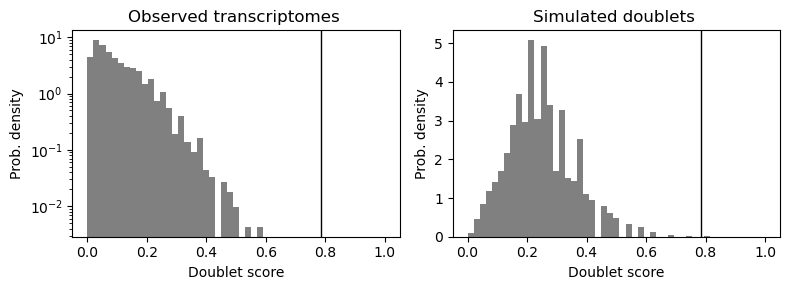

In [18]:
sc.pl.scrublet_score_distribution(d2_dz)

#### Save our results to a qc folder

In [19]:
intermediate_directory = '/Users/stanleydale/user_generated/breault-lab/single-cell/analysis/qc'
sc.write(f'{intermediate_directory}/doublet_egfDuod_D2_DZ.h5ad', d2_dz)